#  Projeto 01 - Concessão de cartões de crédito 

## Etapa 1 — Entendimento do Negócio (CRISP-DM)

### Contexto do problema

Este projeto trata da concessão de crédito, com o objetivo de prever a inadimplência de clientes no momento da solicitação de um cartão de crédito. A inadimplência é definida como atraso igual ou superior a 90 dias em um período de 12 meses. A proposta é utilizar apenas informações disponíveis no momento da análise para estimar esse risco.

---
### Objetivo de negócio

Apoiar a tomada de decisão na concessão de crédito, buscando:

- Reduzir prejuízos com inadimplência  
- Aprovar clientes com baixo risco  
- Equilibrar risco e retorno da carteira  

Na prática, o modelo deve auxiliar na decisão de aprovar, recusar ou ajustar condições de crédito.

---

### Objetivo da modelagem

Desenvolver um modelo de classificação que estime a probabilidade de inadimplência com base nos dados disponíveis no momento da solicitação.

---

### Impacto dos erros

- Falso positivo: aprovar cliente inadimplente → prejuízo financeiro  
- Falso negativo: recusar cliente bom → perda de receita  

O modelo deve equilibrar esses riscos conforme o contexto do negócio.

---

### Métricas de avaliação

Devido ao desbalanceamento esperado entre classes, serão utilizadas múltiplas métricas:

- **ROC-AUC**: mede a capacidade do modelo de separar bons e maus pagadores independentemente de um ponto de corte. Importante para avaliar o desempenho geral do modelo.  
- **Precision**: indica a proporção de clientes classificados como inadimplentes que realmente são inadimplentes. Importante para evitar aprovações arriscadas.  
- **Recall**: mede a capacidade de identificar corretamente os clientes inadimplentes. Essencial para reduzir perdas financeiras.  
- **F1-score**: equilíbrio entre precision e recall, útil quando há necessidade de balancear identificação de risco e controle de erros.  

Neste projeto, será dado maior peso ao recall da classe inadimplente, devido ao custo associado à concessão de crédito a clientes de alto risco.

---

### Hipóteses iniciais

- Histórico de atrasos aumenta o risco de inadimplência  
- Maior endividamento está associado a maior risco  
- Renda impacta a capacidade de pagamento  
- Tempo de relacionamento pode influenciar o risco  

---

### Planejamento

O projeto seguirá as etapas do CRISP-DM:

1. Entendimento do negócio  
2. Análise exploratória dos dados  
3. Preparação dos dados  
4. Engenharia de variáveis  
5. Modelagem  
6. Avaliação  
7. Conclusões  

## Etapa 2 — Entendimento dos Dados (CRISP-DM)

### Visão geral dos dados

Nesta etapa, são analisadas as variáveis disponíveis para compreensão de sua estrutura, significado e potencial impacto no problema de previsão de inadimplência. A base contém informações de clientes no momento da solicitação de crédito, com uma linha por cliente e colunas representando suas características. Ao todo, são 15 variáveis explicativas e 1 variável resposta.

---

### Variável resposta

- **mau**: indica se o cliente é inadimplente (True) ou adimplente (False). Essa variável será o alvo do modelo preditivo.

---

### Tipos de variáveis

As variáveis podem ser agrupadas da seguinte forma:

- **Categóricas binárias**: sexo, posse_de_veiculo, posse_de_imovel  
- **Categóricas nominais**: tipo_renda, educacao, estado_civil, tipo_residencia  
- **Numéricas discretas**: qtd_filhos, idade, tempo_emprego, qt_pessoas_residencia  
- **Binárias (0/1)**: possui_celular, possui_fone_comercial, possui_fone, possui_email  

Essa classificação é importante para definir estratégias de tratamento e modelagem.

---

### Dicionário de dados

| Variável                  | Descrição                                                                 | Tipo        |
|--------------------------|--------------------------------------------------------------------------|-------------|
| sexo                     | M = Masculino; F = Feminino                                              | categórica  |
| posse_de_veiculo         | Y = possui; N = não possui                                               | categórica  |
| posse_de_imovel          | Y = possui; N = não possui                                               | categórica  |
| qtd_filhos               | Quantidade de filhos                                                     | numérica    |
| tipo_renda               | Tipo de renda (assalariado, autônomo, etc.)                              | categórica  |
| educacao                 | Nível educacional                                                        | categórica  |
| estado_civil             | Estado civil                                                             | categórica  |
| tipo_residencia          | Tipo de residência                                                       | categórica  |
| idade                    | Idade em anos                                                            | numérica    |
| tempo_emprego            | Tempo de emprego em anos                                                 | numérica    |
| possui_celular           | Indica posse de celular (1 = sim, 0 = não)                               | binária     |
| possui_fone_comercial    | Indica posse de telefone comercial (1 = sim, 0 = não)                    | binária     |
| possui_fone              | Indica posse de telefone (1 = sim, 0 = não)                              | binária     |
| possui_email             | Indica posse de e-mail (1 = sim, 0 = não)                                | binária     |
| qt_pessoas_residencia    | Quantidade de pessoas na residência                                      | numérica    |
| **mau**                  | Indicador de inadimplência (True = inadimplente, False = adimplente)     | binária     |

---

### Considerações iniciais

- As variáveis incluem características demográficas, financeiras e comportamentais, potencialmente relevantes para avaliação de risco de crédito  
- A presença de variáveis categóricas exige codificação adequada para modelagem  
- Variáveis numéricas podem exigir análise de escala e tratamento de outliers  
- A variável alvo pode apresentar desbalanceamento, o que impacta diretamente a escolha de métricas e técnicas de modelagem  

---

### Próximos passos

A próxima etapa consiste na análise exploratória dos dados (EDA), com foco em:

- Entender a distribuição das variáveis  
- Identificar padrões e relações com a inadimplência  
- Detectar valores ausentes e inconsistências  
- Validar ou refinar as hipóteses iniciais  


### Importação de bibliotecas

Aqui eu importei algumas bibliotecas

- **pandas**: manipulação e análise de dados  
- **seaborn e matplotlib**: visualização de dados  
- **scikit-learn**: divisão dos dados, métricas e algoritmos de machine learning  

In [19]:
# Carregando os pacotes

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier

In [23]:
# Carregando dados
df = pd.read_csv('demo01.csv') # cargando o dataset
print ("Número de linhas e colunas da tabela: {}".format(df.shape))

df.head()

Número de linhas e colunas da tabela: (16650, 16)


,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,possui_celular,possui_fone_comercial,possui_fone,possui_email,qt_pessoas_residencia,mau
0,M,Y,Y,0,Working,Secondary / secondary special,Married,House / apartment,58.832877,3.106849,1,0,0,0,2.0,False
1,F,N,Y,0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.356164,8.358904,1,0,1,1,1.0,False
2,F,N,Y,0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.356164,8.358904,1,0,1,1,1.0,False
3,M,Y,Y,0,Working,Higher education,Married,House / apartment,46.224658,2.106849,1,1,1,1,2.0,False
4,F,Y,N,0,Working,Incomplete higher,Married,House / apartment,29.230137,3.021918,1,0,0,0,2.0,False


In [26]:
# Estrutura dos dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16650 entries, 0 to 16649
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sexo                   16650 non-null  object 
 1   posse_de_veiculo       16650 non-null  object 
 2   posse_de_imovel        16650 non-null  object 
 3   qtd_filhos             16650 non-null  int64  
 4   tipo_renda             16650 non-null  object 
 5   educacao               16650 non-null  object 
 6   estado_civil           16650 non-null  object 
 7   tipo_residencia        16650 non-null  object 
 8   idade                  16650 non-null  float64
 9   tempo_emprego          16650 non-null  float64
 10  possui_celular         16650 non-null  int64  
 11  possui_fone_comercial  16650 non-null  int64  
 12  possui_fone            16650 non-null  int64  
 13  possui_email           16650 non-null  int64  
 14  qt_pessoas_residencia  16650 non-null  float64
 15  ma

### Observações iniciais

- O conjunto de dados possui 16.650 registros e 16 variáveis  
- Não há valores nulos em nenhuma das colunas, o que simplifica a etapa de tratamento de dados  
- As variáveis estão distribuídas entre tipos categóricos (object), numéricos (int64 e float64) e binários (bool)
- Variáveis categóricas (object) precisarão ser transformadas em formato numérico para modelagem  
- A variável alvo (mau) está no formato booleano, podendo ser convertida para 0 e 1  
- Variáveis como idade e tempo_emprego estão como float, embora representem quantidades contínuas em anos, o que pode exigir validação ou arredondamento dependendo do contexto  
- A variável qt_pessoas_residencia também está como float, o que é no minimo estranho já que representa uma contagem e não existem "meia pessoa"

### Análise univariada

Agora vou realizar uma análise univariada das variáveis com o objetivo de compreender suas distribuições, identificar padrões, possíveis anomalias e características relevantes para o problema de negócio. Inicialmente, será analisada a variável resposta (mau), seguida de alguns exemplos de variáveis explicativas. As demais variáveis podem ser exploradas de forma complementar para aprofundamento da análise.

In [32]:
print(df['mau'].value_counts())
print("\nTaxa de inadimplentes:")
print(df['mau'].mean())

mau
False    16260
True       390
Name: count, dtype: int64

Taxa de inadimplentes:
0.023423423423423424


### Distribuição da variável resposta - mau

A análise da variável resposta (mau) indica:

- 16.260 clientes adimplentes (False)  
- 390 clientes inadimplentes (True)  

A taxa de inadimplência observada é de aproximadamente 2,34%. O conjunto de dados apresenta um forte desbalanceamento entre as classes, com predominância significativa de clientes adimplentes. Isso indica, a primeira vista, uma boa base de cleintes que honram suas dívidas.

### Implicações para o modelo

O desbalanceamento impacta diretamente a modelagem e avaliação:

- Modelos podem apresentar alta acurácia mesmo sem identificar corretamente os inadimplentes  
- A acurácia isoladamente pode ser enganosa, pois um modelo que classifica todos os clientes como adimplentes ainda atingiria cerca de 97% de acerto, sem utilidade prática (Overfiting)
- É necessário dar maior atenção à identificação da classe minoritária (inadimplentes)  

Dessa forma, métricas como recall, precision, F1-score e ROC-AUC tornam-se mais relevantes.

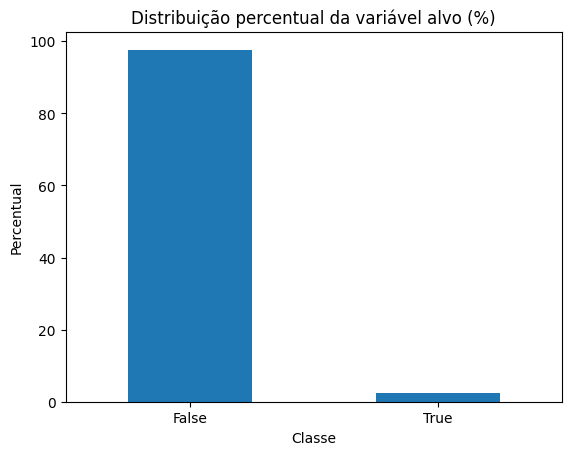

In [37]:
(df[var].value_counts(normalize=True) * 100).plot.bar()
plt.title('Distribuição percentual da variável alvo (%)')
plt.xlabel('Classe')
plt.ylabel('Percentual')
plt.xticks(rotation=0)
plt.show()

A visualização confirma o forte desbalanceamento da variável alvo, com muito mais clientes adimplentes. A baixa proporção de inadimplentes reforça a necessidade de utilizar métricas adequadas e técnicas específicas durante a modelagem, a fim de garantir que o modelo seja capaz de identificar corretamente os casos de maior risco.

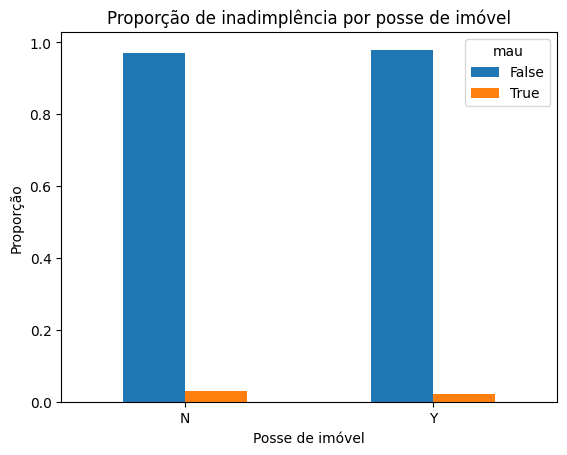

In [42]:
var = 'posse_de_imovel'

ax = pd.crosstab(df[var], df['mau'], normalize='index').plot.bar()

ax.set_title('Proporção de inadimplência por posse de imóvel')
ax.set_xlabel('Posse de imóvel')
ax.set_ylabel('Proporção')

plt.xticks(rotation=0)
plt.show()

A análise indica que não há diferença significativa na proporção de inadimplência entre clientes que possuem e não possuem imóvel. Provavelmente essa variável possui pouco poder de previsão para o problema em questão, contribuindo de forma limitada para a identificação de risco de crédito.

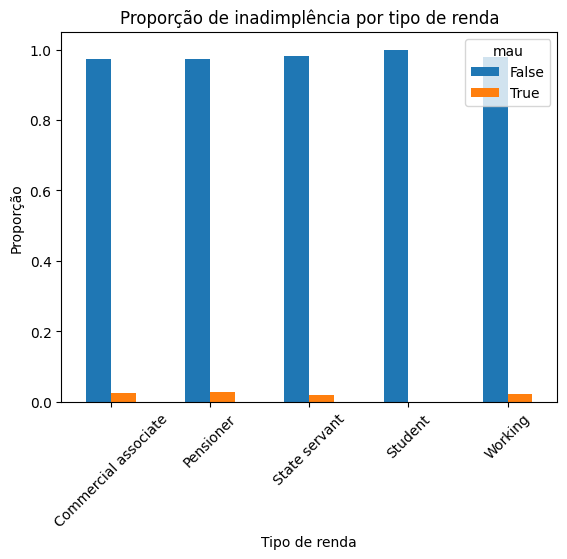

In [44]:
var = 'tipo_renda'

ax = pd.crosstab(df[var], df['mau'], normalize='index').plot.bar()

ax.set_title('Proporção de inadimplência por tipo de renda')
ax.set_xlabel('Tipo de renda')
ax.set_ylabel('Proporção')

plt.xticks(rotation=45)
plt.show()

Poucas variações na proporção de inadimplência entre os diferentes tipos de renda. Embora existam diferenças entre categorias, essas variações não são suficientemente expressivas para indicar forte poder discriminatório de forma isolada. Ainda assim, a variável pode contribuir para o modelo quando combinada com outras características dos clientes.

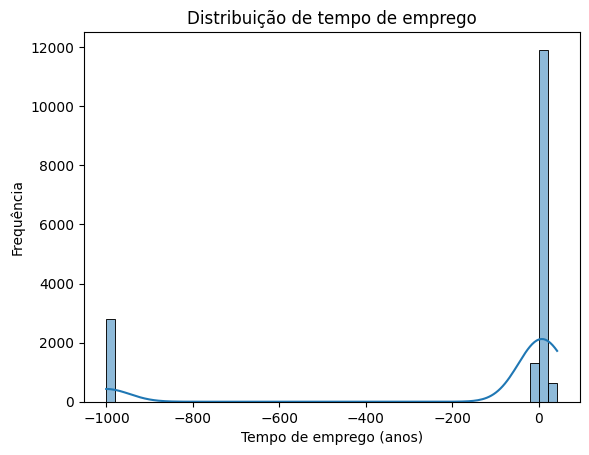

In [49]:
var = "tempo_emprego"

sns.histplot(df[var], bins=50, kde=True)
plt.title('Distribuição de tempo de emprego')
plt.xlabel('Tempo de emprego (anos)')
plt.ylabel('Frequência')
plt.show()

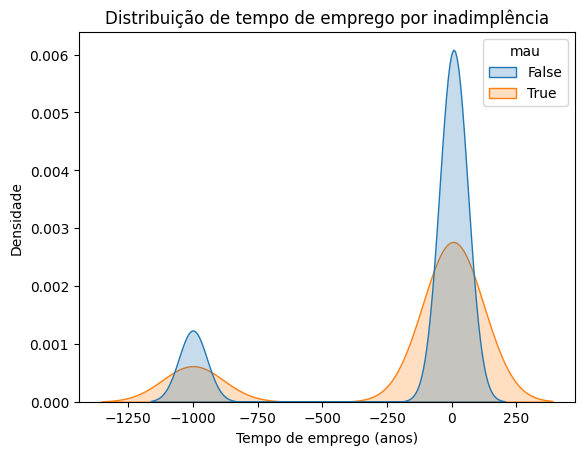

In [51]:
sns.kdeplot(data=df, x=var, hue='mau', fill=True, common_norm=False)

plt.title('Distribuição de tempo de emprego por inadimplência')
plt.xlabel('Tempo de emprego (anos)')
plt.ylabel('Densidade')
plt.show()

A análise revelou a presença de valores inconsistentes (ex: -1000), que não possuem significado prático para a variável e provavelmente representam dados ausentes ou erro de registro. Esses valores serão tratados como dados faltantes nas próximas etapas. Após desconsiderar esses casos, observa-se que a maior parte dos clientes possui baixo tempo de emprego, com concentração próxima a zero. Ao comparar adimplentes e inadimplentes, há grande sobreposição entre os grupos, mas com leve indicação de que clientes com menor tempo de emprego apresentam maior risco de inadimplência.

---
A variável apresenta potencial preditivo moderado, especialmente como indicadora de estabilidade profissional, podendo contribuir para o modelo quando combinada com outras variáveis.

In [57]:
# Quantidade de valores inválidos
qtd_invalidos = (df['tempo_emprego'] < 0).sum()
print(f"Valores inválidos encontrados: {qtd_invalidos}")

# Tratamento: substituir valores negativos por NA
df.loc[df['tempo_emprego'] < 0, 'tempo_emprego'] = pd.NA

# Criar variável indicadora de ausência
df['sem_emprego_info'] = df['tempo_emprego'].isna().astype(int)

# Validação
print("\nValores ausentes após tratamento:")
print(df['tempo_emprego'].isna().sum())

Valores inválidos encontrados: 0

Valores ausentes após tratamento:
2793


Após o tratamento, os valores inconsistentes foram convertidos em dados ausentes. Além disso, foi criada uma variável indicadora (sem_emprego_info) para capturar a ausência de informação, que pode ser relevante para o modelo, já que a falta de dados também pode estar associada ao risco de crédito.

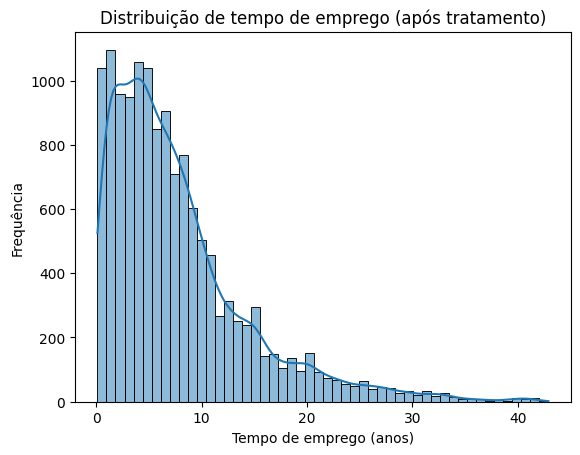

In [62]:
var = "tempo_emprego"

sns.histplot(df[var], bins=50, kde=True)

plt.title('Distribuição de tempo de emprego (após tratamento)')
plt.xlabel('Tempo de emprego (anos)')
plt.ylabel('Frequência')

plt.show()

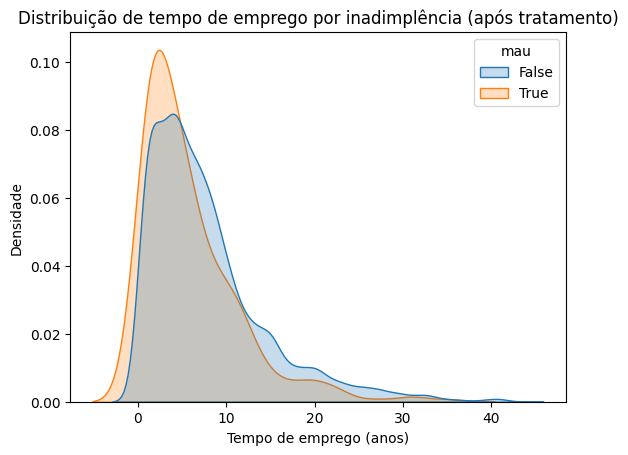

In [64]:
sns.kdeplot(data=df, x=var, hue='mau', fill=True, common_norm=False)

plt.title('Distribuição de tempo de emprego por inadimplência (após tratamento)')
plt.xlabel('Tempo de emprego (anos)')
plt.ylabel('Densidade')

plt.show()

Inadimplentes (laranja) estão mais concentrados nos menores valores
Adimplentes (azul) se distribuem mais ao longo

<Figure size 640x480 with 0 Axes>

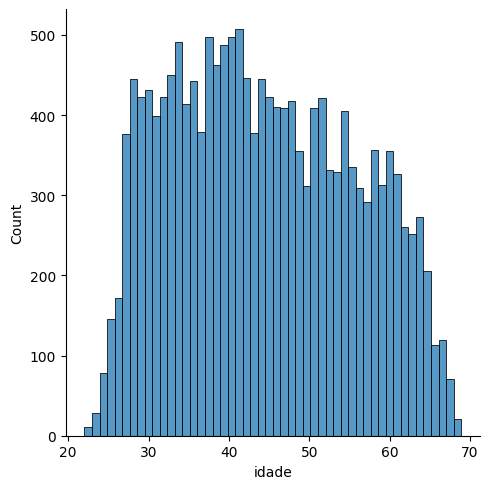

In [68]:
plt.clf()
var = "idade"

sns.displot(df, x = var, bins = 50)
plt.show()

In [69]:
#Fim do Exercício

### Entendimento dos dados - Bivariadas

Entender a alteração da inadimplência indicada pela variável resposta (```AtrasoRelevante2anos```) e as variáveis explicativas (demais). Para isto, vamos calcular a taxa de inadimplentes (qtd inadimplentes / total) para diferentes grupos definidos pelas variáveis explicativas.


C:\Users\luan\AppData\Local\Temp\ipykernel_25552\4160224667.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(cat_srs)


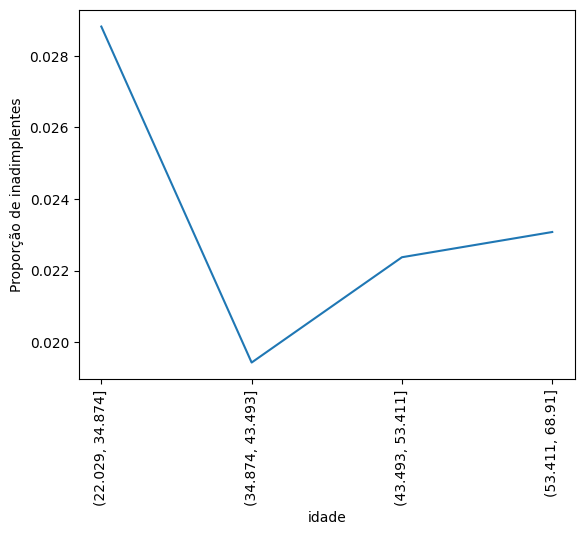

In [71]:
var = 'idade'
cat_srs, bins = pd.qcut(df[var], 4, retbins=True)
g = df.groupby(cat_srs)
biv = g['mau'].mean()

ax = biv.plot.line()
ax.set_ylabel("Proporção de inadimplentes")
ticks = plt.xticks(range(len(biv.index.values)), biv.index.values, rotation = 90)

### <span style="color:blue">Tarefa 03 - Bivariada </span>
<span style="color:blue"> Com base no código da célula anterior, construa uma análise bivariada para a variável  ```tempo_emprego```.  Em seguida, insira uma célula de markdown e conclua se a variável parece discriminar risco de crédito. </span>




C:\Users\luan\AppData\Local\Temp\ipykernel_25552\4284403881.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(cat_srs)


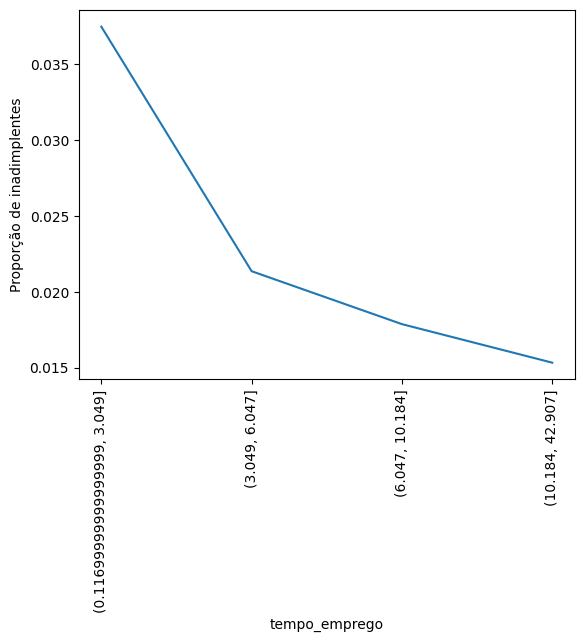

In [75]:
var = 'tempo_emprego'
cat_srs, bins = pd.qcut(df[var], 4, retbins=True)
g = df.groupby(cat_srs)
biv = g['mau'].mean()

ax = biv.plot.line()
ax.set_ylabel("Proporção de inadimplentes")
ticks = plt.xticks(range(len(biv.index.values)), biv.index.values, rotation = 90)

A medida que o tempo de emprego aumenta a inadiplência diminui. Com mais tempo de emprego espera-se também mais estabilidade e até mesmo possiveis meios de arcar com as dívidas em caso de imprevisto.

## Etapa 3 Crisp-DM: Preparação dos dados
Nessa etapa realizamos tipicamente as seguintes operações com os dados:
- seleção
Neste caso, os dados já estão pré-selecionados
- limpeza
Precisaremos identificar e tratar dados faltantes
- construção
Neste primeiro exercício não faremos construção de novas variáveis
- integração
Temos apenas uma fonte de dados, não é necessário agregação
- formatação
Os dados já se encontram em formatos úteis

Os dados já estão pré-selecionados, construídos e integrados, mas há dados faltantes que serão eliminados na próxima célula

In [78]:
metadata = pd.DataFrame(df.dtypes, columns = ['tipo'])

metadata['n_categorias'] = 0

for var in metadata.index:
    metadata.loc[var,'n_categorias'] = len(df.groupby([var]).size())
    
metadata

,tipo,n_categorias
sexo,object,2
posse_de_veiculo,object,2
posse_de_imovel,object,2
qtd_filhos,int64,8
tipo_renda,object,5
educacao,object,5
estado_civil,object,5
tipo_residencia,object,6
idade,float64,5298
tempo_emprego,float64,3004


In [79]:
def convert_dummy(df, feature,rank=0):
    pos = pd.get_dummies(df[feature], prefix=feature)
    mode = df[feature].value_counts().index[rank]
    biggest = feature + '_' + str(mode)
    pos.drop([biggest],axis=1,inplace=True)
    df.drop([feature],axis=1,inplace=True)
    df=df.join(pos)
    return df

In [80]:
for var in metadata[metadata['tipo'] == 'object'].index:
    df = convert_dummy(df, var)

In [81]:
df

,qtd_filhos,idade,tempo_emprego,possui_celular,possui_fone_comercial,possui_fone,possui_email,qt_pessoas_residencia,mau,sem_emprego_info,...,educacao_Lower secondary,estado_civil_Civil marriage,estado_civil_Separated,estado_civil_Single / not married,estado_civil_Widow,tipo_residencia_Co-op apartment,tipo_residencia_Municipal apartment,tipo_residencia_Office apartment,tipo_residencia_Rented apartment,tipo_residencia_With parents
0,0,58.832877,3.106849,1,0,0,0,2.0,False,0,...,False,False,False,False,False,False,False,False,False,False
1,0,52.356164,8.358904,1,0,1,1,1.0,False,0,...,False,False,False,True,False,False,False,False,False,False
2,0,52.356164,8.358904,1,0,1,1,1.0,False,0,...,False,False,False,True,False,False,False,False,False,False
3,0,46.224658,2.106849,1,1,1,1,2.0,False,0,...,False,False,False,False,False,False,False,False,False,False
4,0,29.230137,3.021918,1,0,0,0,2.0,False,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16645,0,54.109589,9.884932,1,0,0,0,2.0,True,0,...,False,True,False,False,False,False,False,False,False,False
16646,0,43.389041,7.380822,1,1,1,0,2.0,True,0,...,False,False,False,False,False,False,False,False,False,False
16647,0,30.005479,9.800000,1,1,0,0,2.0,True,0,...,False,False,False,False,False,False,False,False,False,False
16648,0,30.005479,9.800000,1,1,0,0,2.0,True,0,...,False,False,False,False,False,False,False,False,False,False


## Etapa 4 Crisp-DM: Modelagem
Nessa etapa que realizaremos a construção do modelo. Os passos típicos são:

- Selecionar a técnica de modelagem
Utilizaremos a técnica de floresta aleatória (**random forest**), pois é uma técnica bastante versátil e robusta que captura bem padrões complexos nos dados, relativamente fácil de se usar e que costuma produzir excelentes resultados para uma classificação como estas. Vamos ver esse algoritmo em detalhes mais adiante no curso, mas pense nele por enquanto como uma regra complexa baseada nas variáveis explicativas que classifica o indivíduo como inadimplente ou não. Mais adiante no curso vamos extrair mais dessa técnica.

- Desenho do teste
Antes de rodar o modelo precisamos construir um desenho do teste que será realizado. Para desenvolver um modelo como este, é considerado uma boa prática dividir a base em duas, uma chamada ```treinamento```, onde o algoritmo 'aprende', e outra chamada ```teste```, onde o algoritmo é avaliado. Essa prática fornece uma métrica de avaliação mais fidedigna do algoritmo, falaremos mais detalhes em lições futuras.

- Avaliação do modelo
Faremos a avaliação do nosso modelo através do percentual de acerto, avaliando a classificação do modelo (inadimplente e não inadimplente) e comparando com o estado real armazenado na variável resposta (```AtrasoRelevante2anos```). Esse percentual de acerto é frequentemente chamado de acurácia (**obs:** nunca usar assertividade... a**ss**ertivo não é aquele que a**c**erta, e sim "*adj.: em que o locutor declara algo, positivo ou negativo, do qual assume inteiramente a validade; declarativo*." a**C**ertivo está errado ;)
#### Dividindo a base em treino e teste



In [83]:
# Tirando a v. resposta da base de treinamento
x = df.drop("mau",axis = 1)
y = df["mau"]

# Tirando ID da base de treinamento e teste
x_train, x_test, y_train, y_test = train_test_split(x, y)

In [85]:
x_train

,qtd_filhos,idade,tempo_emprego,possui_celular,possui_fone_comercial,possui_fone,possui_email,qt_pessoas_residencia,sem_emprego_info,sexo_M,...,educacao_Lower secondary,estado_civil_Civil marriage,estado_civil_Separated,estado_civil_Single / not married,estado_civil_Widow,tipo_residencia_Co-op apartment,tipo_residencia_Municipal apartment,tipo_residencia_Office apartment,tipo_residencia_Rented apartment,tipo_residencia_With parents
13039,0,47.745205,NaN,1,0,0,0,2.0,1,False,...,False,False,False,False,False,False,False,False,False,False
8623,0,37.134247,10.863014,1,0,1,0,2.0,0,True,...,False,False,False,False,False,False,False,False,False,False
7839,1,36.254795,7.473973,1,0,0,0,3.0,0,True,...,False,True,False,False,False,False,False,False,False,False
6752,2,38.980822,16.301370,1,0,0,0,4.0,0,False,...,False,False,False,False,False,False,False,False,False,False
7639,0,62.232877,NaN,1,0,0,0,2.0,1,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9485,0,35.791781,6.263014,1,1,0,0,2.0,0,False,...,False,False,False,False,False,True,False,False,False,False
9741,0,28.405479,3.449315,1,1,0,0,2.0,0,True,...,False,False,False,False,False,False,False,False,False,False
12838,0,43.895890,24.800000,1,0,0,0,2.0,0,False,...,False,False,False,False,False,False,False,False,True,False
1479,1,29.493151,6.016438,1,0,0,1,3.0,0,False,...,False,True,False,False,False,False,False,False,False,False


### Rodando o modelo
A função RandomForestClassifier gera a estrutura da floresta aleatória, e o parâmetro ```n_estimator``` define o número de árvores na floresta. Normalmente a acurácia do modelo tende a aumentar com o número de árvores, pelo menos até um certo limite - e aumenta também o recurso computacional demandado. Você pode alterar esse parâmetro e verificar se a acurácia do seu modelo melhora - não recomendamos valores muito altos. Vá alterando aos poucos e percebendo como o tempo aumenta com os seus recursos. Não é necessário ir muito além de umas 100 árvores.

In [87]:
# Treinar uma Random Forest com 5 árvores

clf = RandomForestClassifier(n_estimators=5)
clf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=5)

In [88]:
# Calculando a acuracia

y_pred = clf.predict(x_test)
acc = metrics.accuracy_score(y_test, y_pred)
print('Acurácia: {0:.2f}%'.format(acc*100))

Acurácia: 97.45%


In [89]:
# Matriz de confusão

tab = pd.crosstab(index = y_pred, columns = y_test)
print(tab.iloc[1, 0] / (tab.iloc[1, 0] + tab.iloc[0, 0])) # por essa
print(tab.iloc[1, 1] / (tab.iloc[1, 1] + tab.iloc[0, 1])) # e por essa
tab

0.00860162202015237
0.24468085106382978


mau,False,True
row_0,,
False,4034,71
True,35,23


In [90]:
clf = RandomForestClassifier(n_estimators=5)
clf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=5)

In [91]:
y_pred = clf.predict(x_test)
acc = metrics.accuracy_score(y_test, y_pred)
print('Acurácia: {0:.2f}%'.format(acc*100))

Acurácia: 97.50%


In [92]:
tab = pd.crosstab(index = y_pred, columns = y_test)
print(tab.iloc[1, 0] / (tab.iloc[1, 0] + tab.iloc[0, 0]))
print(tab.iloc[1, 1] / (tab.iloc[1, 1] + tab.iloc[0, 1]))
tab

0.006881297616121897
0.19148936170212766


mau,False,True
row_0,,
False,4041,76
True,28,18


### <span style="color:blue">Tarefa 04 - Bivariada </span>
<span style="color:blue"> Para essa tarefa, crie três células extras, copie nelas o código das três células anteriores (na mesma ordem) e altere o parâmetro ```n_estimators=``` da função ```RandomForestClassifier``` e insira uma quantidade maior que 3 nesse parâmetro. Rode as três células anteriores para calcular a acurácia do modelo e veja se você consegue uma acurácia melhor. </span>

In [94]:
clf = RandomForestClassifier(n_estimators=90)
clf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=90)

In [95]:
# Calculando a acuracia

y_pred = clf.predict(x_test)
acc = metrics.accuracy_score(y_test, y_pred)
print('Acurácia: {0:.2f}%'.format(acc*100))

Acurácia: 97.67%


In [96]:
# Matriz de confusão

tab = pd.crosstab(index = y_pred, columns = y_test)
print(tab.iloc[1, 0] / (tab.iloc[1, 0] + tab.iloc[0, 0]))
print(tab.iloc[1, 1] / (tab.iloc[1, 1] + tab.iloc[0, 1]))
tab

0.0061440157286802655
0.23404255319148937


mau,False,True
row_0,,
False,4044,72
True,25,22


## Etapa 5 Crisp-DM: Avaliação dos resultados
A etapa final do CRISP. Neste casp, a nossa avaliação termina com a acurácia. Mas em problemas futuros aprofundaremos mais - a ideia seria avaliar o impacto do uso do modelo no negócio, ou seja, o quanto o resultado financeiro melhora em detrimento da utilização do modelo.

Como um exemplo simples, considere que um cliente bom pagador deixa (em média) 5 '*dinheiros*' de lucro, e um mau pagador deixa (em média) 100 '*dinheiros*' de prejuízo.

de acordo com a matriz de confusão:

| Decisão   | lucro dos bons    | lucro dos maus | total  |
| --------- |:-----------------:|:--------------:| ------:|
| Aprovador | 4042 x 5          | 72 x (-100)    | 13.010 |
| Reprovar  |  27 x 5           | 22 x (-100)    | -2.065 |

Estariamos evitando, portanto, um prejuízo de -2.145 '*dinheiros*' - o que na prática significa um aumento no lucro.


## Etapa 6 Crisp-DM: Implantação
Nessa etapa colocamos em uso o modelo desenvolvido, normalmente implementando o modelo desenvolvido em um motor de crédito que toma as decisões com algum nível de automação - tipicamente aprovando automaticamente clientes muito bons, negando automaticamente clientes muito ruins, e enviando os intermediários para análise manual.